In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from Part 1
charging_sessions = pd.read_parquet('intermediate_data/charging_sessions.parquet')

### 2. KIPs

#### KPI 1: Hourly kWh
We start with the KPI Hourly kWh delivered it works by splitting each session's energy into hourly chunks based on how long the car was plugged in. It then piles those chunks into hourly buckets to show the total load for each site.

#### KPI 2: Hourly Capacity

This KPI calculates the percentage of charging spots occupied per hour. It is calculated using a method analogous to KPI 1.

#### KPI 3:

This KPI quantifies service quality as the ratio of delivered to credibly requested energy, aggregated weekly for stability. Credible demand is derived empirically from observed charging behavior by filtering implausible requests and low-activity weeks. This preparation ensures the KPI reflects real operational load rather than noisy user inputs.

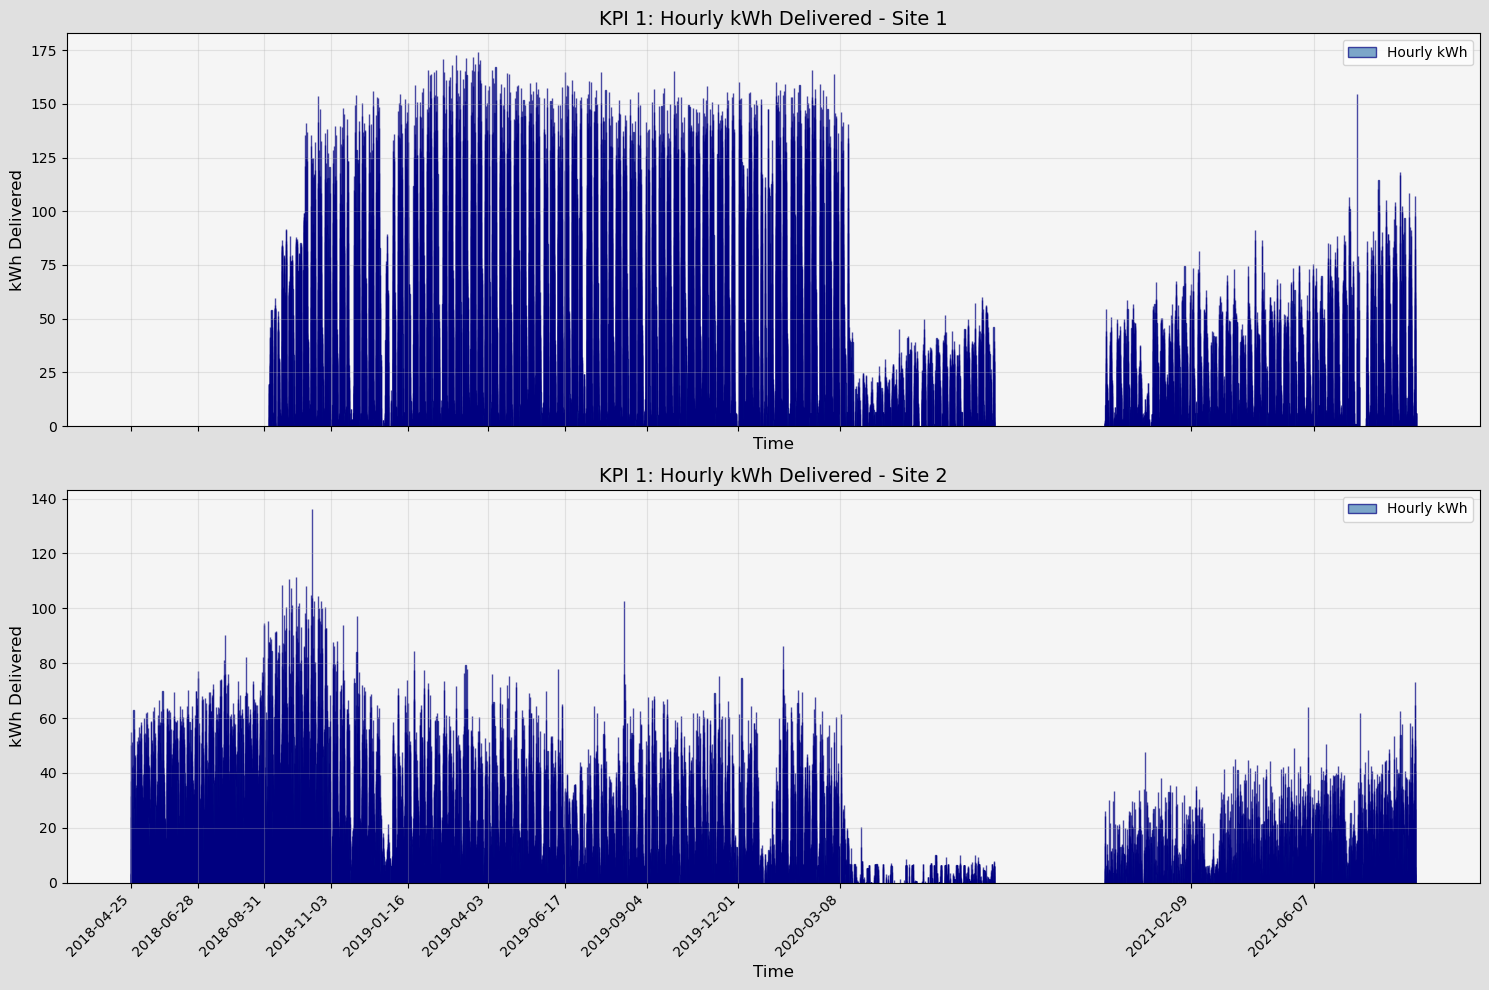

In [3]:
# KPI 1: Hourly kWh Delivered
# Distributes each session's total kWh into hourly buckets assuming constant power output

df = charging_sessions.copy()

# Ensure all timestamps are in UTC for consistent arithmetic
df['connection_time'] = pd.to_datetime(df['connection_time'], utc=True)
df['disconnect_time'] = pd.to_datetime(df['disconnect_time'], utc=True)
df['done_charging_time'] = pd.to_datetime(df['done_charging_time'], utc=True)

# Use done_charging_time as the end of energy delivery; fall back to disconnect_time if missing
df['energy_end_time'] = df['done_charging_time'].fillna(df['disconnect_time'])
df['start_time'] = df['connection_time']

rows = []

for _, row in df.iterrows():
    start = row['start_time']
    end = row['energy_end_time']
    site = row['site_id']
    kwh_total = row['kwh_delivered']
    
    total_duration_hours = (end - start).total_seconds() / 3600
    
    # Skip near-zero duration sessions to avoid division by zero
    if total_duration_hours > 0.001:
        
        # Assume constant power: average kW = total energy / total hours
        avg_power_kw = kwh_total / total_duration_hours

        # Build the range of clock-hours this session spans (floored to the hour)
        start_hour = start.floor('h')
        end_hour = end.floor('h')
        hours = pd.date_range(start=start_hour, end=end_hour, freq='h')
        
        # For each clock-hour, calculate how much of the session overlaps with it
        for hour in hours:
            hour_start = hour
            hour_end = hour + pd.Timedelta(hours=1)

            # Overlap = intersection of [start, end) and [hour_start, hour_end)
            overlap_seconds = (min(end, hour_end) - max(start, hour_start)).total_seconds()
            overlap_hours = max(0, overlap_seconds / 3600)
            
            if overlap_hours > 0:
                # Energy in this bucket = constant power * overlap duration
                kwh_chunk = avg_power_kw * overlap_hours
                rows.append({'site_id': site, 'hour': hour, 'kwh_hourly': kwh_chunk})

# Aggregate: sum all session contributions per site per hour
usage_df = pd.DataFrame(rows)
hourly_kwh = usage_df.groupby(['site_id', 'hour'])['kwh_hourly'].sum().reset_index()

# --- Plotting: one subplot per site ---
site_ids = sorted(hourly_kwh['site_id'].unique())
fig, axes = plt.subplots(len(site_ids), 1, figsize=(15, 5 * len(site_ids)), sharex=True)
fig.patch.set_facecolor('#E0E0E0')

if len(site_ids) == 1:
    axes = [axes]

for ax, site_id in zip(axes, site_ids):
    site_data = hourly_kwh[hourly_kwh['site_id'] == site_id].sort_values('hour')

    ax.set_facecolor('#F5F5F5')
    ax.bar(site_data['hour'], site_data['kwh_hourly'],
           width=0.04, color='steelblue', edgecolor='navy', alpha=0.7, label='Hourly kWh')

    ax.set_title(f'KPI 1: Hourly kWh Delivered - Site {site_id}', fontsize=14)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('kWh Delivered', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    tick_interval = max(len(site_data)//12, 1)
    ax.set_xticks(site_data['hour'].iloc[::tick_interval])
    ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in site_data['hour'].iloc[::tick_interval]],
                       rotation=45, ha='right')

plt.tight_layout()
plt.show()

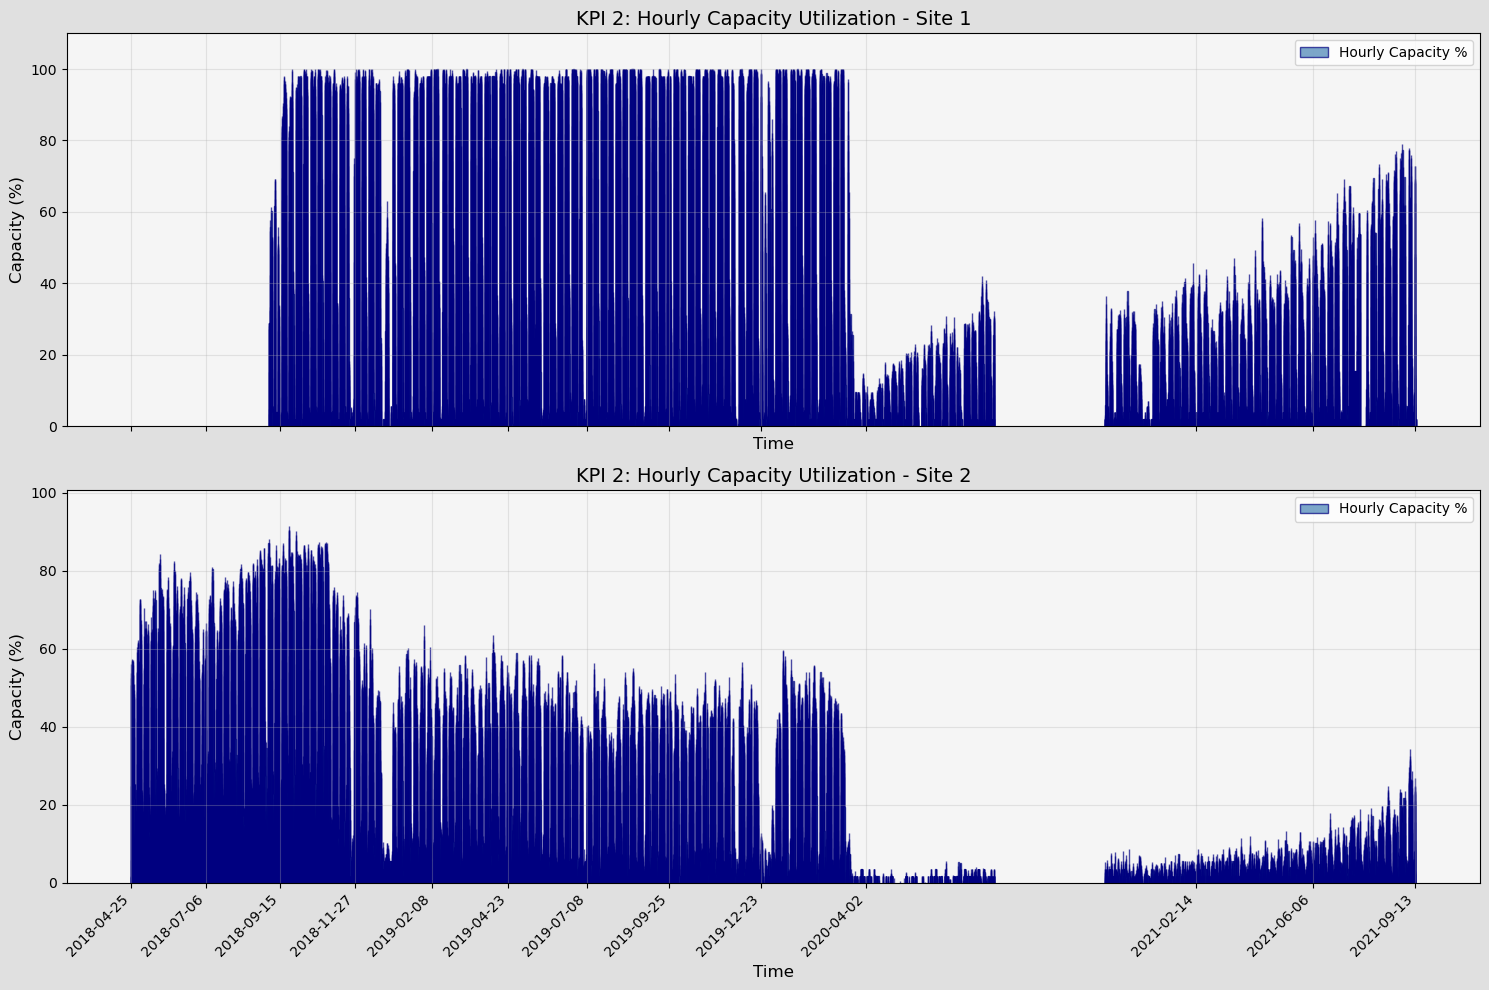

In [4]:
# KPI 2: Hourly Capacity Utilization
# Calculated analogous to KPI 1

df = charging_sessions.copy()

df['connection_time'] = pd.to_datetime(df['connection_time'], utc=True)
df['disconnect_time'] = pd.to_datetime(df['disconnect_time'], utc=True)

total_stations = df.groupby('site_id')['station_id'].nunique().to_dict()

rows = []

for _, row in df.iterrows():
    start = row['connection_time']
    end = row['disconnect_time']
    site = row['site_id']
    
    start_hour = start.floor('h')
    end_hour = end.floor('h')
    hours = pd.date_range(start=start_hour, end=end_hour, freq='h')
    
    for hour in hours:
        hour_start = hour
        hour_end = hour + pd.Timedelta(hours=1)
        overlap = (min(end, hour_end) - max(start, hour_start)).total_seconds() / 3600
        if overlap > 0:
            rows.append({'site_id': site, 'hour': hour, 'fraction': overlap})

usage_df = pd.DataFrame(rows)
hourly_usage = usage_df.groupby(['site_id', 'hour'])['fraction'].sum().reset_index()

hourly_usage['capacity_percent'] = hourly_usage.apply(lambda x: (x['fraction'] / total_stations[x['site_id']]) * 100, axis=1)
hourly_usage['hour'] = pd.to_datetime(hourly_usage['hour'])

# Plotting - separate graph for each site (hourly)
site_ids = sorted(hourly_usage['site_id'].unique())
fig, axes = plt.subplots(len(site_ids), 1, figsize=(15, 5 * len(site_ids)), sharex=True)
fig.patch.set_facecolor('#E0E0E0')

if len(site_ids) == 1:
    axes = [axes]

for ax, site_id in zip(axes, site_ids):
    site_data = hourly_usage[hourly_usage['site_id'] == site_id].sort_values('hour')

    ax.set_facecolor('#F5F5F5')
    ax.bar(site_data['hour'], site_data['capacity_percent'],
           width=0.04, color='steelblue', edgecolor='navy', alpha=0.7, label='Hourly Capacity %')

    ax.set_title(f'KPI 2: Hourly Capacity Utilization - Site {site_id}', fontsize=14)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Capacity (%)', fontsize=12)
    ax.set_ylim(0, max(100, site_data['capacity_percent'].max() * 1.1))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    tick_interval = max(len(site_data)//12, 1)
    ax.set_xticks(site_data['hour'].iloc[::tick_interval])
    ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in site_data['hour'].iloc[::tick_interval]],
                       rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [5]:
# KPI 3 - Weighted Fulfillment (Preperation)

# Quantifying intent quality (session level) - Distribution of kWhRequested
kpi3_df = charging_sessions.copy()
kpi3_df['kwh_requested'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75])

count    47822.000000
mean        25.278167
std         20.888558
min          0.000000
1%           4.000000
5%           6.660000
10%          8.000000
25%         12.000000
50%         19.437500
75%         32.000000
max        215.320000
Name: kwh_requested, dtype: float64

<Axes: xlabel='kwh_requested', ylabel='kwh_delivered'>

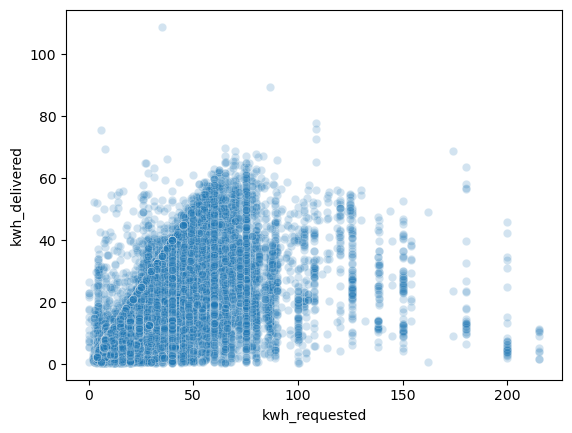

In [6]:
# KPI 3 - Weighted Fulfillment (Preperation)

# Quantifying intent quality (session level) - Relationship between requested and delivered energy
kpi3_df[['kwh_requested', 'kwh_delivered']].corr()
sns.scatterplot(
    data=kpi3_df,
    x='kwh_requested',
    y='kwh_delivered',
    alpha=0.2
)

In [7]:
# KPI 3 - Weighted Fulfillment (Preperation)

# Intent quality by request size 

kpi3_df['request_bin'] = pd.cut(
    kpi3_df['kwh_requested'],
    bins=[0, 1, 5, 10, 20, 50, 100, 200, float('inf')]
)

bin_stats = (
    kpi3_df
    .groupby('request_bin', observed=False)
    .agg(
        sessions=('kwh_requested', 'count'),
        median_requested=('kwh_requested', 'median'),
        median_delivered=('kwh_delivered', 'median'),
        median_ratio=('kwh_delivered',lambda x: (x / kpi3_df.loc[x.index, 'kwh_requested']).median()),
        p95_ratio=('kwh_delivered',lambda x: (x / kpi3_df.loc[x.index, 'kwh_requested']).quantile(0.95))
    )
)

bin_stats

,sessions,median_requested,median_delivered,median_ratio,p95_ratio
request_bin,,,,,
"(0.0, 1.0]",1,0.256,0.767,2.996094,2.996094
"(1.0, 5.0]",979,4.000,3.059,0.804250,4.112948
"(5.0, 10.0]",9107,8.000,5.487,0.658625,1.005329
"(10.0, 20.0]",17311,16.000,9.501,0.618750,0.993617
"(20.0, 50.0]",15366,30.690,15.522,0.529610,1.000699
"(50.0, 100.0]",4492,61.940,28.357,0.429155,0.904094
"(100.0, 200.0]",540,126.000,26.008,0.206687,0.446007
"(200.0, inf]",10,215.320,7.333,0.034056,0.052052


In [8]:
# KPI 3 - Weighted Fulfillment (Preperation)

# Defining valid user intent window (session filtering)
valid_intent_sessions = kpi3_df[
    (kpi3_df['kwh_requested'] >= 10) &
    (kpi3_df['kwh_requested'] <= 100)
]

# Coverage check – How much data is retained after intent filtering
coverage = {
    'session_retention_pct': len(valid_intent_sessions) / len(kpi3_df) * 100,
    'energy_retention_pct': (
        valid_intent_sessions['kwh_requested'].sum() /
        kpi3_df['kwh_requested'].sum()
    ) * 100
}

coverage

{'session_retention_pct': 58.86956655442287,
 'energy_retention_pct': np.float64(88.54639973301755)}

In [9]:
# KPI 3 - Weighted Fulfillment (Preperation)

# Site-level impact – Are entire sites being distorted?
site_retention = (
    valid_intent_sessions
    .groupby('site_id')['kwh_requested']
    .sum() /
    kpi3_df.groupby('site_id')['kwh_requested'].sum()
)

site_retention.describe()

count    2.000000
mean     0.873109
std      0.044181
min      0.841868
25%      0.857489
50%      0.873109
75%      0.888729
max      0.904349
Name: kwh_requested, dtype: float64

In [10]:
# KPI 3 - Weighted Fulfillment (Preperation)

# Weekly scale analysis – Identify low-activity weeks
weekly_valid_energy = (
    valid_intent_sessions
    .set_index('connection_time')
    .groupby('site_id')
    .resample('W')['kwh_requested']
    .sum()
)
weekly_valid_energy.describe(percentiles=[0.1, 0.25, 0.5])

count     336.000000
mean     3185.700539
std      2714.201928
min         0.000000
10%        26.500000
25%       920.882500
50%      2684.915000
max      9921.750000
Name: kwh_requested, dtype: float64

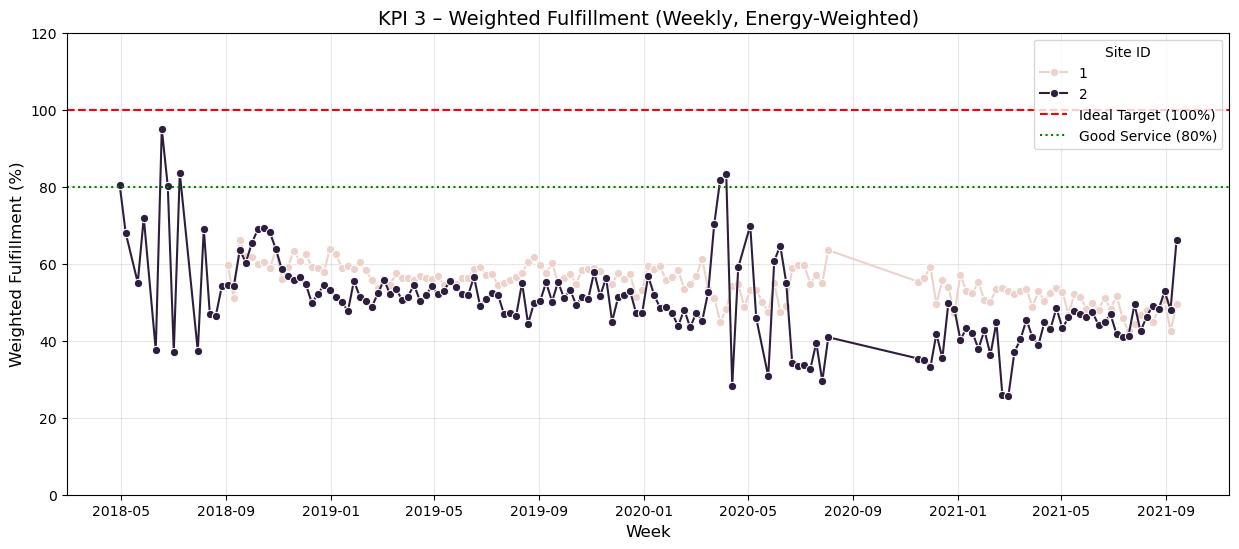

In [11]:
# KPI 3 - Weighted Fulfillment (Implementation)

kpi3_df = charging_sessions.copy()
kpi3_df['connection_time'] = pd.to_datetime(kpi3_df['connection_time'])

# Defining "Valid Intent"
# Only physically plausible requests (10–100 kWh)
valid_intent = kpi3_df[
    (kpi3_df['kwh_requested'] >= 10) &
    (kpi3_df['kwh_requested'] <= 100)
].copy()

# Weekly timeline
valid_intent['week_start'] = (
    valid_intent['connection_time']
    .dt.to_period('W')
    .dt.start_time
)

# Calculating total requested energy per site per week
weekly_volume = (
    valid_intent
    .groupby(['site_id', 'week_start'])['kwh_requested']
    .sum()
    .reset_index()
)

# Identify site-weeks with sufficient demand (10th percentile ≈ 26.5 kWh)
active_weeks = weekly_volume[weekly_volume['kwh_requested'] >= 26.5]

# Removeing low-activity weeks that would distort the KPI
final_sessions = valid_intent.merge(
    active_weeks[['site_id', 'week_start']],
    on=['site_id', 'week_start'],
    how='inner'
)

# KPI calculation (energy-weighted fulfillment)
kpi3_weighted_fulfillment = (
    final_sessions
    .groupby(['site_id', 'week_start'])[['kwh_delivered', 'kwh_requested']]
    .sum()
    .reset_index()
)

kpi3_weighted_fulfillment['weighted_fulfillment'] = (
    kpi3_weighted_fulfillment['kwh_delivered'] /
    kpi3_weighted_fulfillment['kwh_requested']
) * 100

# Visualization
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=kpi3_weighted_fulfillment,
    x='week_start',
    y='weighted_fulfillment',
    hue='site_id',
    marker='o'
)

plt.axhline(100, color='red', linestyle='--', label='Ideal Target (100%)')
plt.axhline(80, color='green', linestyle=':', label='Good Service (80%)')

plt.title('KPI 3 – Weighted Fulfillment (Weekly, Energy-Weighted)', fontsize=14)
plt.ylabel('Weighted Fulfillment (%)', fontsize=12)
plt.xlabel('Week', fontsize=12)
plt.legend(title='Site ID', loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 120)
plt.show()

In [12]:
# Save intermediate data for subsequent notebooks
hourly_kwh.to_parquet('intermediate_data/hourly_kwh.parquet')